### Apartado 4 (Clasificación)

En este apartado se entrenan y evalúan dos modelos de clasificación sobre el conjunto
de datos music_classification.csv:

- Un **árbol de decisión** (DecisionTreeClassifier) usando los hiperparámetros óptimos
  obtenidos en el Ejercicio 3.
- Una **regresión logística** (LogisticRegression) para clasificación multiclase.

Se analizan tres esquemas de validación distintos:

1. **Hold-out único 75–25**  
2. **10 Hold-outs repetidos 75–25**  
3. **Validación cruzada 5-Fold**

En cada caso se calculan las siguientes métricas de clasificación:

- Accuracy  
- Cohen's Kappa  
- Precision, Recall y F1-Score (a nivel de clase y agregadas)  
- Matriz de confusión agregada

El objetivo final es comparar el comportamiento de la **Regresión Logística** y del
**Árbol de Decisión** bajo diferentes esquemas de evaluación.


# Importamos los datos y las librerías

In [1]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("music_classification.csv")
display(df.head())

X = df.drop(columns=["Class"]).values
y = df["Class"].values

# Nombres de clases (para matrices de confusión y comparaciones)
class_names = np.unique(y)
print("Clases:", class_names)

,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,0.854,0.564,1.0,-4.964,1,0.0485,0.017100,0.0849,0.8990,134.071,234596.0,4,5
1,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.1010,0.5690,116.454,251733.0,4,10
2,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.3940,0.7870,147.681,109667.0,4,6
3,0.853,0.597,10.0,-6.528,0,0.0555,0.021200,0.1220,0.5690,107.033,173968.0,4,5
4,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.1720,0.0918,199.060,229960.0,4,10


Clases: [ 0  1  2  3  4  5  6  7  8  9 10]


# Cargamos los modelos que vamos a usar

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def make_tree_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("clf", DecisionTreeClassifier(min_samples_leaf=20, ccp_alpha=0.0))
    ])

def make_logreg_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=6000
        ))
    ])


En el arbol de clasificación hemos imputado los valores NA por la moda. Esto solo se va a ver reflejado en la variable key.

En el modelo de regresión logística hemos imputado y también estandarizado las variables ya que de esta manera es como mejor funciona.

# Métricas que vamos a usar 

In [4]:
def compute_global_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": acc,
        "kappa": kappa,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro
    }


def per_class_report(y_true, y_pred, class_names):
    y_true = y_true.astype(str)
    y_pred = y_pred.astype(str)
    class_names = list(map(str, class_names))

    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )

    cls_rows = {cls: vals for cls, vals in report_dict.items() if cls in class_names}
    df_rep = pd.DataFrame(cls_rows).T[["precision", "recall", "f1-score", "support"]]
    return df_rep



def confusion_df(y_true, y_pred, class_names):
    y_true = y_true.astype(str)
    y_pred = y_pred.astype(str)
    class_names = list(map(str, class_names))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    return pd.DataFrame(cm, index=class_names, columns=class_names)



## 4.A Hold-out único 75–25

En este primer esquema se realiza una única partición aleatoria:

- 75% entrenamiento
- 25% prueba

Usamos la misma partición para comparar:

- Árbol de decisión (con hiperparámetros óptimos del Ejercicio 3).
- Regresión logística multinomial.

Para cada modelo se calculan:

- Accuracy
- Cohen's Kappa
- Precision, Recall y F1-Score por clase
- Matriz de confusión

Señalaremos el F1-macro ya que en la base de datos hay muchas clases y no todas tienen la misma cantidad de ejemplos. Esta métrica muestra mejor el rendimiento real cuando hay muchas clases y están desequilibradas. 


In [5]:
# Partición 75/25 (hold-out único)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# Árbol de decisión
tree = make_tree_model().fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

metrics_tree_ho = compute_global_metrics(y_test, y_pred_tree)

print("=== Hold-out único 75/25 — Árbol de decisión ===")
print("Métricas globales:")
display(pd.DataFrame([metrics_tree_ho]))

print("\nMétricas por clase (Precision, Recall, F1):")
display(per_class_report(y_test, y_pred_tree, class_names))



print("\nMatriz de confusión (filas: reales, columnas: predichas):")
display(confusion_df(y_test, y_pred_tree, class_names))


# Regresión logística
logreg = make_logreg_model().fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)

metrics_log_ho = compute_global_metrics(y_test, y_pred_log)

print("\n\n=== Hold-out único 75/25 — Regresión logística ===")
print("Métricas globales:")
display(pd.DataFrame([metrics_log_ho]))

print("\nMétricas por clase (Precision, Recall, F1):")
display(per_class_report(y_test, y_pred_log, class_names))

print("\nMatriz de confusión (filas: reales, columnas: predichas):")
display(confusion_df(y_test, y_pred_log, class_names))



=== Hold-out único 75/25 — Árbol de decisión ===
Métricas globales:


,accuracy,kappa,precision_macro,recall_macro,f1_macro
0,0.419204,0.310984,0.446659,0.453182,0.446032



Métricas por clase (Precision, Recall, F1):


,precision,recall,f1-score,support
0,0.500000,0.602564,0.546512,156.0
1,0.108108,0.034985,0.052863,343.0
2,0.407661,0.481811,0.441645,1237.0
3,0.351931,0.257862,0.297641,318.0
4,0.551724,0.640000,0.592593,100.0
5,0.439560,0.412371,0.425532,97.0
6,0.597561,0.676796,0.634715,362.0
7,0.258647,0.265842,0.262195,647.0
8,0.812500,0.722222,0.764706,144.0
9,0.496842,0.508621,0.502662,464.0



Matriz de confusión (filas: reales, columnas: predichas):


...

,accuracy,kappa,precision_macro,recall_macro,f1_macro
0,0.477217,0.363461,0.483973,0.498207,0.476435



Métricas por clase (Precision, Recall, F1):


,precision,recall,f1-score,support
0,0.555556,0.673077,0.608696,156.0
1,0.000000,0.000000,0.000000,343.0
2,0.420729,0.718674,0.530746,1237.0
3,0.462963,0.235849,0.312500,318.0
4,0.585586,0.650000,0.616114,100.0
5,0.495652,0.587629,0.537736,97.0
6,0.662198,0.682320,0.672109,362.0
7,0.297297,0.068006,0.110692,647.0
8,0.862069,0.868056,0.865052,144.0
9,0.567816,0.532328,0.549499,464.0



Matriz de confusión (filas: reales, columnas: predichas):


,0,1,2,3,4,5,6,7,8,9,10
0,105,0,0,15,15,0,0,7,0,10,4
1,0,0,9,0,0,17,20,1,27,43,226
2,0,0,75,0,0,8,12,1,5,54,163
3,18,0,0,65,7,0,0,6,0,3,1
4,24,0,0,8,57,0,0,0,0,8,0
5,0,0,2,0,0,247,6,0,3,64,40
6,0,0,21,1,0,38,44,4,41,119,379
7,13,0,0,4,1,0,0,125,0,0,1
8,0,0,3,0,0,3,5,0,247,3,203
9,22,0,15,3,17,52,19,1,2,293,207


La Regresión Logística obtiene mejores resultados globales que el Árbol de Decisión, mostrando mayor accuracy, F1-macro y Kappa. Esto sugiere que la estructura del problema se ajusta mejor a un modelo lineal, mientras que el árbol puede estar sobreajustando a características específicas del conjunto de entrenamiento. Además, la distribución desbalanceada de clases afecta más negativamente al árbol, que tiende a favorecer clases mayoritarias. En conjunto, bajo esta partición, la Regresión Logística generaliza mejor y de forma más estable.

Llama la atención el hecho de que el género 1 no se calsifique correctamente ni una sola vez. Esto puede ser debido a un fuerte desbalance de datos y a la falta de un patrón distintivo en sus características. Aunque existen 343 ejemplos reales, el modelo no predice ninguna porque optimiza la precisión global priorizando clases más frecuentes (2, 6, 8). Además, la distribución de los atributos musicales de la clase 1 se solapa con otras clases, lo que dificulta su separación en el espacio de características.

## 4.B 10 Hold-outs repetidos 75–25

En este esquema se repite 10 veces la partición aleatoria 75–25.  
En cada repetición:

1. Se realiza un nuevo train_test_split estratificado.
2. Se entrena el modelo con el 75% de entrenamiento.
3. Se evalúa en el 25% de prueba.

Se almacenan las métricas globales (Accuracy, Kappa, Precision, Recall, F1 macro)
y al final se reportan:

- la **media**
- la **desviación estándar**

para cada modelo.

Además, se acumula una **matriz de confusión agregada** sumando las matrices
de todas las repeticiones.


In [6]:
def repeated_holdout_results_extended(make_model, X, y, n_repeats=10):
    metrics_list = []
    cm_sum = np.zeros((len(class_names), len(class_names)), dtype=int)

    y_true_total = []
    y_pred_total = []

    for seed in range(n_repeats):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.25, random_state=seed, stratify=y
        )
        
        model = make_model().fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        metrics_list.append(compute_global_metrics(y_te, y_pred))
        cm_sum += confusion_matrix(y_te, y_pred, labels=class_names)

        y_true_total.extend(y_te)
        y_pred_total.extend(y_pred)

    df_metrics = pd.DataFrame(metrics_list)
    summary = df_metrics.agg(["mean", "std"]).T
    cm_agg = pd.DataFrame(cm_sum, index=class_names, columns=class_names)

    return summary, cm_agg, np.array(y_true_total), np.array(y_pred_total)


# Árbol
summary_tree_rep, cm_tree_rep, y_true_tree_rep, y_pred_tree_rep = repeated_holdout_results_extended(
    make_tree_model, X, y, n_repeats=10
)

print("=== 10 Hold-outs 75/25 — Árbol de decisión ===")
display(summary_tree_rep)

print("\nMatriz de confusión agregada:")
display(cm_tree_rep)

print("\nMétricas por clase (Precision, Recall, F1):")
display(per_class_report(y_true_tree_rep, y_pred_tree_rep, class_names))


# Regresión Logística
summary_log_rep, cm_log_rep, y_true_log_rep, y_pred_log_rep = repeated_holdout_results_extended(
    make_logreg_model, X, y, n_repeats=10
)

print("\n\n=== 10 Hold-outs 75/25 — Regresión logística ===")
display(summary_log_rep)

print("\nMatriz de confusión agregada:")
display(cm_log_rep)

print("\nMétricas por clase (Precision, Recall, F1):")
display(per_class_report(y_true_log_rep, y_pred_log_rep, class_names))


=== 10 Hold-outs 75/25 — Árbol de decisión ===


,mean,std
accuracy,0.427695,0.006747
kappa,0.318696,0.007698
precision_macro,0.458419,0.007728
recall_macro,0.457686,0.010532
f1_macro,0.453182,0.009054



Matriz de confusión agregada:


,0,1,2,3,4,5,6,7,8,9,10
0,885,0,0,186,149,0,0,150,0,120,70
1,0,137,179,0,0,188,782,0,221,390,1533
2,0,82,886,0,0,98,497,0,59,438,1120
3,183,0,0,652,37,0,0,66,0,34,34
4,216,0,0,55,384,0,0,22,0,235,58
5,0,37,92,0,0,2257,372,0,20,571,271
6,0,261,381,0,0,423,1487,0,346,891,2681
7,155,0,0,90,18,0,0,1170,0,3,4
8,0,27,39,0,0,15,256,0,2423,56,1818
9,183,113,341,44,173,609,968,13,42,2470,1354



Métricas por clase (Precision, Recall, F1):


...

,mean,std
accuracy,0.468593,0.005338
kappa,0.352866,0.006471
precision_macro,0.475470,0.006795
recall_macro,0.487556,0.007352
f1_macro,0.469162,0.006068



Matriz de confusión agregada:


,0,1,2,3,4,5,6,7,8,9,10
0,983,0,0,136,171,0,0,168,1,87,14
1,0,0,107,0,0,187,259,7,216,397,2257
2,0,0,712,0,0,52,193,2,63,556,1602
3,161,0,0,685,68,0,3,56,0,28,5
4,210,0,0,56,533,0,0,24,0,141,6
5,0,0,74,0,0,2287,114,0,19,704,422
6,0,0,286,2,0,392,539,5,338,1029,3879
7,121,0,0,43,8,0,0,1260,0,5,3
8,0,0,22,0,0,16,47,0,2403,28,2118
9,208,0,191,38,191,487,206,18,33,2910,2028



Métricas por clase (Precision, Recall, F1):


,precision,recall,f1-score,support
0,0.561714,0.630128,0.593958,1560.0
1,0.000000,0.000000,0.000000,3430.0
2,0.415561,0.708973,0.523989,12370.0
3,0.385073,0.223899,0.283158,3180.0
4,0.661836,0.680915,0.671240,1006.0
5,0.455167,0.549485,0.497898,970.0
6,0.645498,0.631768,0.638559,3620.0
7,0.305556,0.083308,0.130921,6470.0
8,0.817121,0.875000,0.845070,1440.0
9,0.558837,0.518558,0.537945,4634.0


Ambos modelos muestran métricas más estables (baja desviación estándar) respecto al hold-out simple, indicando menor dependencia de una única partición. La regresión logística vuelve a superar al árbol de decisión en todas las métricas globales (accuracy ≈ 0.47 vs 0.43; f1_macro ≈ 0.47 vs 0.45), lo que refuerza su mejor capacidad de generalización con este conjunto de datos. El árbol presenta mayor variabilidad y peor rendimiento, lo que sugiere mayor sensibilidad al muestreo y posible sobreajuste. En conjunto, este esquema valida de manera más robusta que la regresión logística es la mejor opción entre ambos modelos.

## 4.C Validación cruzada 5-Fold

En este esquema se divide el conjunto de datos en 5 particiones (folds) estratificadas.
Para cada fold:

- se entrena el modelo con 4 folds,
- se valida en el fold restante.

Para obtener una **matriz de confusión agregada** y métricas globales,
utilizamos cross_val_predict, que genera las predicciones out-of-fold
para todos los ejemplos.

Sobre estas predicciones se calculan:

- Accuracy
- Cohen's Kappa
- Precision, Recall y F1 macro
- Matriz de confusión agregada


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Árbol
tree_base = make_tree_model()
y_pred_tree_cv = cross_val_predict(tree_base, X, y, cv=cv)

metrics_tree_cv = compute_global_metrics(y, y_pred_tree_cv)
cm_tree_cv = confusion_df(y, y_pred_tree_cv, class_names)

print("=== Validación cruzada 5-Fold — Árbol de decisión ===")
print("Métricas globales (out-of-fold):")
display(pd.DataFrame([metrics_tree_cv]))

print("\nMatriz de confusión agregada:")
display(cm_tree_cv)

print("\nMétricas por clase (Precision, Recall, F1):")
display(per_class_report(y, y_pred_tree_cv, class_names))


# Regresión logística
log_base = make_logreg_model()
y_pred_log_cv = cross_val_predict(log_base, X, y, cv=cv)

metrics_log_cv = compute_global_metrics(y, y_pred_log_cv)
cm_log_cv = confusion_df(y, y_pred_log_cv, class_names)

print("\n\n=== Validación cruzada 5-Fold — Regresión logística ===")
print("Métricas globales (out-of-fold):")
display(pd.DataFrame([metrics_log_cv]))

print("\nMatriz de confusión agregada:")
display(cm_log_cv)

print("\nMétricas por clase (Precision, Recall, F1):")
display(per_class_report(y, y_pred_log_cv, class_names))



=== Validación cruzada 5-Fold — Árbol de decisión ===
Métricas globales (out-of-fold):


,accuracy,kappa,precision_macro,recall_macro,f1_macro
0,0.431429,0.322782,0.458728,0.462425,0.456904



Matriz de confusión agregada:


,0,1,2,3,4,5,6,7,8,9,10
0,366,0,0,63,68,0,0,56,0,39,33
1,0,51,70,0,0,83,341,0,86,144,598
2,0,33,320,0,0,35,205,0,23,162,494
3,84,0,0,253,16,0,0,29,0,11,9
4,85,0,0,17,175,0,0,10,0,79,21
5,0,20,36,0,0,924,140,0,3,202,122
6,0,125,162,0,0,168,582,0,127,337,1086
7,70,0,0,33,7,0,0,461,0,3,2
8,0,9,14,0,0,6,113,0,1013,17,682
9,66,37,134,18,86,255,364,7,13,975,569



Métricas por clase (Precision, Recall, F1):


...

,accuracy,kappa,precision_macro,recall_macro,f1_macro
0,0.468382,0.351993,0.474029,0.483647,0.466051



Matriz de confusión agregada:


,0,1,2,3,4,5,6,7,8,9,10
0,405,0,0,50,70,0,0,63,0,31,6
1,0,0,45,0,0,75,91,4,84,161,913
2,0,0,286,0,0,22,73,1,20,216,654
3,70,0,0,271,23,1,1,21,0,13,2
4,101,0,0,23,201,0,0,9,0,51,2
5,0,0,29,0,0,918,51,0,6,277,166
6,0,0,107,1,0,147,215,3,128,400,1586
7,60,0,0,20,4,0,0,490,0,2,0
8,0,0,8,0,0,6,13,0,945,12,870
9,83,0,74,20,85,192,75,5,13,1167,810



Métricas por clase (Precision, Recall, F1):


,precision,recall,f1-score,support
0,0.540721,0.648000,0.589520,625.0
1,0.000000,0.000000,0.000000,1373.0
2,0.413466,0.713477,0.523538,4949.0
3,0.388587,0.224843,0.284861,1272.0
4,0.651442,0.674129,0.662592,402.0
5,0.442731,0.519380,0.478002,387.0
6,0.650142,0.634416,0.642183,1447.0
7,0.317109,0.083108,0.131700,2587.0
8,0.820771,0.850694,0.835465,576.0
9,0.562500,0.509709,0.534805,1854.0


#### Comparación gráfica 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metrics = ["accuracy", "f1_macro", "kappa"]

rows = []

# LOGISTIC REGRESSION
row_log = {"Modelo": "LogisticRegression"}
for m in metrics:
    row_log[f"{m}_Holdout"]  = metrics_log_ho[m]
    row_log[f"{m}_10H"]      = summary_log_rep.loc[m, "mean"]
    row_log[f"{m}_5F"]       = metrics_log_cv[m]
rows.append(row_log)

# DECISION TREE
row_tree = {"Modelo": "DecisionTreeClassifier"}
for m in metrics:
    row_tree[f"{m}_Holdout"]  = metrics_tree_ho[m]
    row_tree[f"{m}_10H"]      = summary_tree_rep.loc[m, "mean"]
    row_tree[f"{m}_5F"]       = metrics_tree_cv[m]
rows.append(row_tree)

df_cls_comp = pd.DataFrame(rows).set_index("Modelo")
display(df_cls_comp)


,accuracy_Holdout,accuracy_10H,accuracy_5F,f1_macro_Holdout,f1_macro_10H,f1_macro_5F,kappa_Holdout,kappa_10H,kappa_5F
Modelo,,,,,,,,,
LogisticRegression,0.477217,0.468593,0.468382,0.476435,0.469162,0.466051,0.363461,0.352866,0.351993
DecisionTreeClassifier,0.419204,0.427695,0.431429,0.446032,0.453182,0.456904,0.310984,0.318696,0.322782


In [9]:
def plot_metric(metric_name):
    labels = df_cls_comp.index
    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(10,5))
    plt.bar(x - width, df_cls_comp[f"{metric_name}_Holdout"], width, label="Hold-out simple")
    plt.bar(x,         df_cls_comp[f"{metric_name}_10H"], width, label="10 Hold-outs")
    plt.bar(x + width, df_cls_comp[f"{metric_name}_5F"], width, label="5-Fold")

    plt.xticks(x, labels, rotation=10)
    plt.ylabel(metric_name.upper())
    plt.title(f"Comparación de {metric_name.upper()} entre estrategias de validación")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()


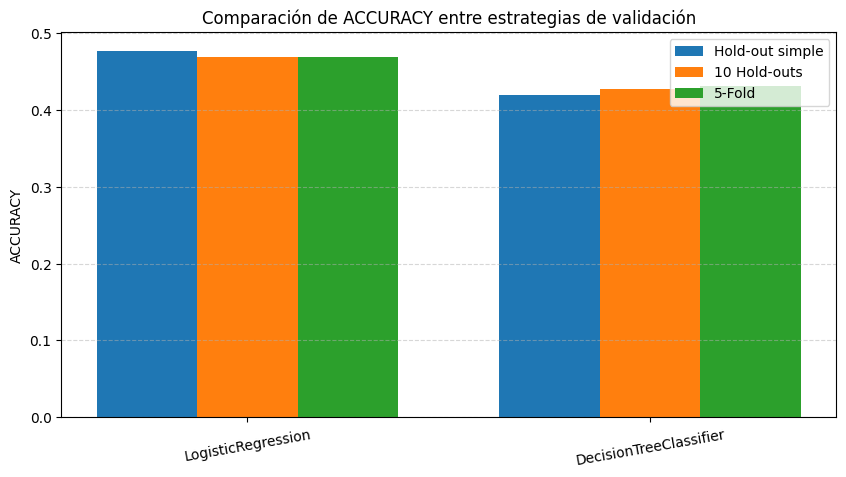

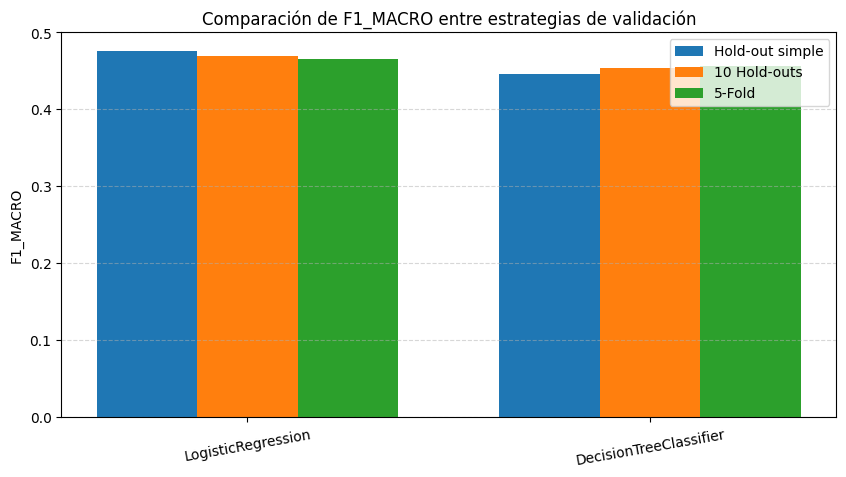

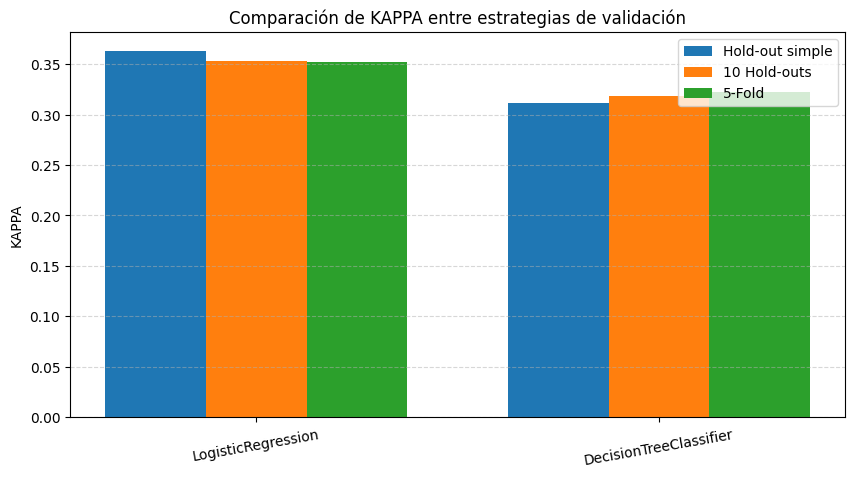

In [10]:
for m in metrics:
    plot_metric(m)


#### Comparación entre modelos y técnicas de validación
Los resultados muestran que la Regresión Logística obtiene sistemáticamente mejores métricas que el Árbol de Decisión en todos los esquemas de validación. Esto se refleja en valores superiores de accuracy, F1-macro y kappa, lo que indica mayor capacidad de generalización y menor sensibilidad a la variación de los datos. El Árbol de Decisión muestra un rendimiento más bajo y variable, lo que sugiere una mayor propensión al sobreajuste y dependencia de la partición utilizada.

En cuanto a las estrategias de validación, el hold-out simple tiende a ofrecer resultados ligeramente más altos, pero es menos fiable porque depende de una sola partición. Los métodos más robustos, como los 10 hold-outs repetidos y especialmente la validación cruzada 5-Fold, proporcionan valores más consistentes y estables, reduciendo la variabilidad y ofreciendo estimaciones más realistas del rendimiento.

En conjunto, la combinación de mejores métricas y estabilidad sugiere que la Regresión Logística es la opción más adecuada para este conjunto de datos, mientras que el Árbol de Decisión puede ser útil por su interpretabilidad, pero no destaca en rendimiento predictivo. Asimismo, para una evaluación rigurosa se recomienda usar validación cruzada o hold-outs repetidos en lugar del hold-out simple.

#### Comparación con la práctica anterior 

Al comparar los resultados obtenidos en este apartado con los de la práctica anterior, se observan diferencias relevantes tanto en el rendimiento como en la naturaleza de los modelos evaluados. En la práctica anterior, los mejores resultados en términos de Accuracy y F1-Macro se alcanzaron con modelos basados en vecinos cercanos, concretamente KNN con valores altos de k, que superaron el 44% de Accuracy y presentaron mayor estabilidad entre métodos de validación. UnoR y ZeroR actuaron como modelos base pero quedaron significativamente por debajo, lo que estableció una referencia mínima de desempeño.

En contraste, en el presente apartado, el rendimiento general de los modelos es ligeramente inferior: ni la Regresión Logística ni el Árbol de Decisión alcanzan las mejores cifras obtenidas previamente con KNN. Entre los dos modelos actuales, la Regresión Logística muestra un desempeño superior de manera consistente frente al Árbol de Decisión en todas las métricas analizadas (Accuracy, F1-Macro y Kappa), lo que sugiere una mayor capacidad de generalización al imponer una frontera lineal que parece adaptarse mejor a este conjunto de datos. El Árbol de Decisión, aunque competitivo, muestra mayor variabilidad y un rendimiento más sensible al método de validación, lo que sugiere cierto sobreajuste incluso tras el ajuste de hiperparámetros.

Respecto a los esquemas de validación, los resultados mantienen el mismo patrón observado en la práctica previa: el hold-out simple tiende a ofrecer valores ligeramente más optimistas, mientras que la validación cruzada 5-Fold proporciona estimaciones más estables y representativas, tanto en este apartado como en el anterior. Asimismo, los 10 hold-outs repetidos actúan como un punto intermedio adecuado, reduciendo la dependencia de una sola partición sin la carga computacional de la validación cruzada.